# Prompt 5A - One-Time IID Evaluation and Final Error Analysis

Prompt 4C froze the final Primary and Global comparator before IID. Predictions were locked before target access. Only these two models were evaluated, and Block A was excluded before IID. IID was never used for tuning.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT=Path('..')
R=ROOT/'outputs/reports'
F=ROOT/'outputs/figures/prompt5a'

## Access order and frozen scope

The access ledger proves one feature read, prediction locking, and then one target read. No model was fitted or changed.

In [2]:
ledger=json.loads((R/'prompt5a_iid_access_ledger.json').read_text())
lock=json.loads((R/'prompt5a_prediction_lock.json').read_text())
display(pd.DataFrame([{'feature reads':ledger['feature_successful_content_reads'],'target reads':ledger['target_successful_content_reads'],'models':ledger['prediction_models'],'prediction rows':ledger['prediction_rows'],'post-target predictions':ledger['model_prediction_calls_after_target_access']}]))

,feature reads,target reads,models,prediction rows,post-target predictions
0,1,1,2,150000,0


## Overall IID performance

MAE remains the Primary metric. MAPE and WAPE are secondary percentage summaries.

,model_id,role,n_rows,mae,rmse,r2,rmsle,median_absolute_error,p90_absolute_error,mean_signed_error,...,top_five_percent_underprediction_rate,p85_to_p95_boundary_mae,top_decile_rows,top_five_percent_rows,boundary_rows,mape_percent,mape_invalid_nonpositive_rows,mape_valid_rows,mape_valid_coverage,wape_percent
0,final_primary_stage3_500k,Primary,75000,62.260626,134.920181,0.676640,0.387157,36.812194,133.121315,-8.108594,...,0.801904,98.839109,7503,3781,7533,33.560168,0,75000,1.0,24.949717
1,final_global_500k,Global comparator,75000,62.444349,137.397192,0.664658,0.387272,36.850210,133.201254,-9.435433,...,0.827030,97.377178,7503,3781,7533,33.529924,0,75000,1.0,25.023341


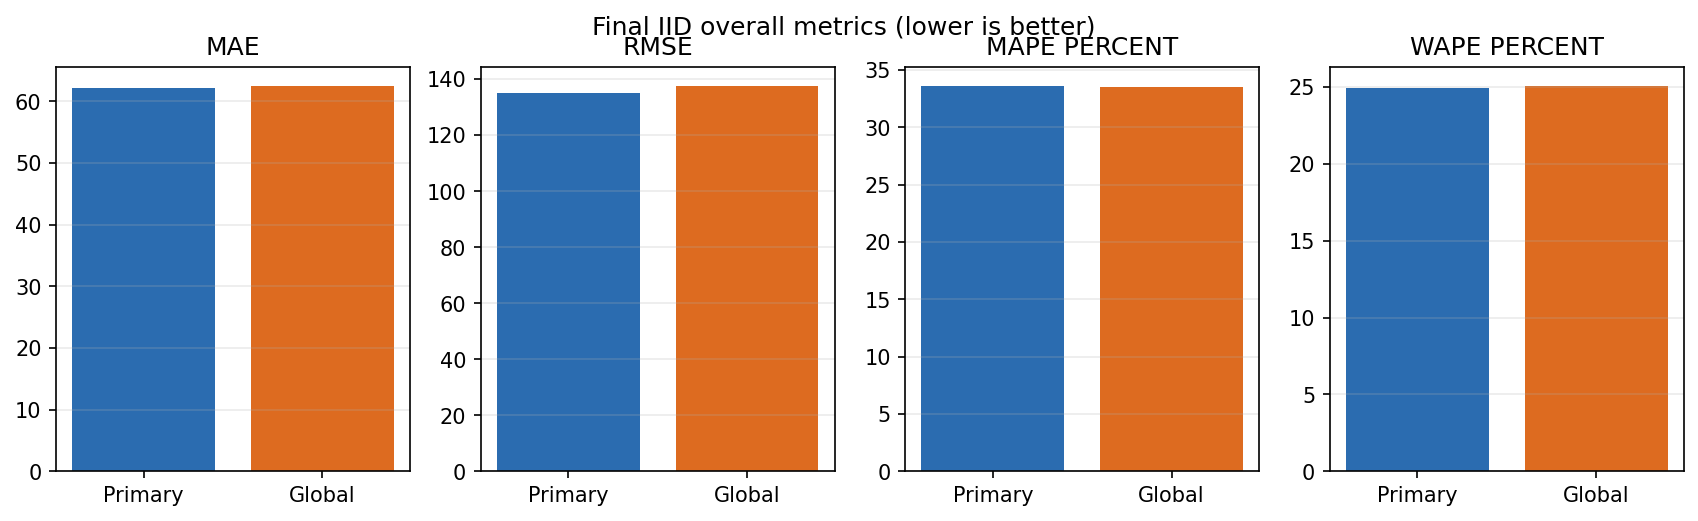

In [3]:
overall=pd.read_csv(R/'prompt5a_iid_overall_metrics.csv')
display(overall)
display(Image(filename=str(F/'01_overall_metric_comparison.png')))

## IID-local target deciles

These deciles use true IID targets only for descriptive error analysis.

,model_id,decile,decile_index,n,target_min,target_max,mean_target,median_target,mean_prediction,median_prediction,mae,mape_percent,mape_invalid_nonpositive_rows,mape_valid_rows,mape_valid_coverage,wape_percent,rmse,mean_signed_error,underprediction_rate
0,final_primary_stage3_500k,D1,1,7719,1.0,70.0,36.073714,37.0,60.126968,48.316459,29.278094,104.078923,0,7719,1.0,81.161850,47.905150,24.053254,0.268299
1,final_primary_stage3_500k,D2,2,7366,71.0,110.0,92.147570,93.0,125.401501,116.064479,41.866583,46.359182,0,7366,1.0,45.434278,62.061448,33.253931,0.238800
2,final_primary_stage3_500k,D3,3,7664,111.0,142.0,126.832203,127.0,151.296722,141.386065,38.524686,30.507627,0,7664,1.0,30.374531,59.257046,24.464519,0.341467
3,final_primary_stage3_500k,D4,4,7338,143.0,171.0,156.838921,157.0,174.756952,165.109747,38.653750,24.739948,0,7338,1.0,24.645509,58.183538,17.918031,0.413737
4,final_primary_stage3_500k,D5,5,7495,172.0,202.0,186.958105,187.0,198.401500,188.554098,41.889122,22.375858,0,7495,1.0,22.405620,63.013669,11.443395,0.478719
5,final_primary_stage3_500k,D6,6,7464,203.0,239.0,220.540863,220.0,222.691550,214.538101,44.656468,20.279286,0,7464,1.0,20.248614,63.747374,2.150687,0.554528
6,final_primary_stage3_500k,D7,7,7456,240.0,282.0,260.035274,260.0,251.983493,243.184530,52.311609,20.127824,0,7456,1.0,20.117120,72.853973,-8.051781,0.615343
7,final_primary_stage3_500k,D8,8,7535,283.0,347.0,312.388587,311.0,293.540280,284.543297,62.252486,19.938875,0,7535,1.0,19.927900,85.878580,-18.848306,0.664234
8,final_primary_stage3_500k,D9,9,7482,348.0,438.0,391.989441,393.0,354.240682,341.930425,81.708484,20.817988,0,7482,1.0,20.844562,107.365292,-37.748759,0.726276
9,final_primary_stage3_500k,D10,10,7481,439.0,14400.0,716.854565,592.0,586.515388,499.075858,192.292490,24.281399,0,7481,1.0,26.824477,370.322588,-130.339177,0.776634


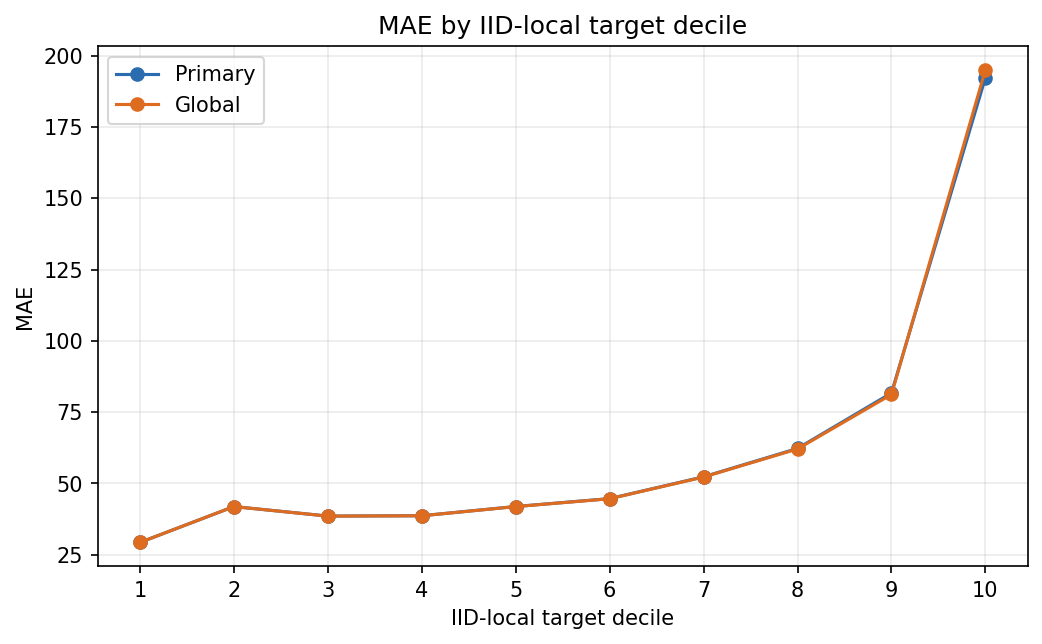

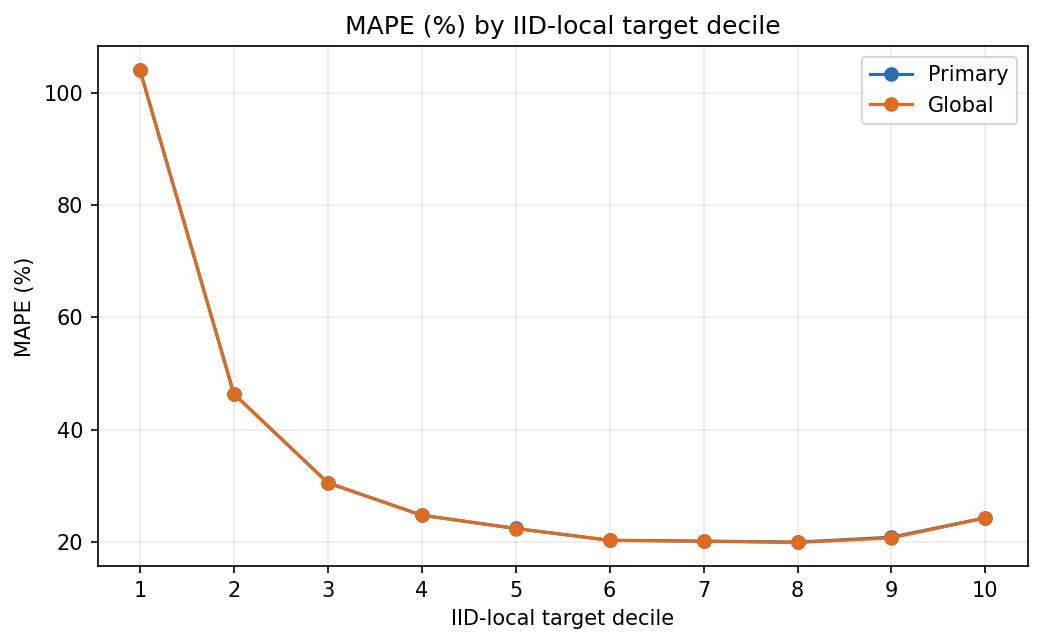

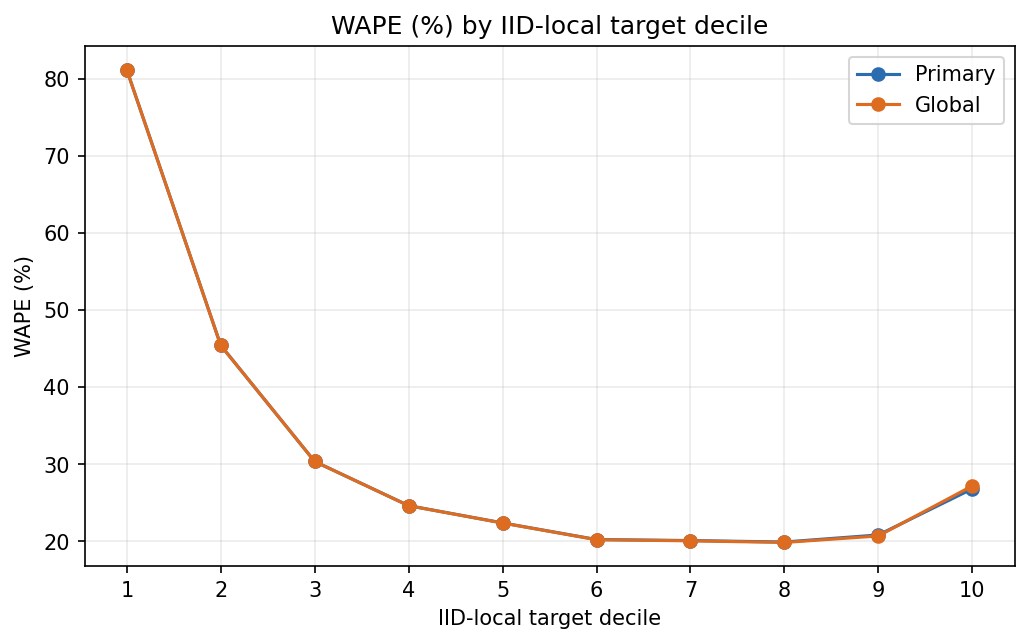

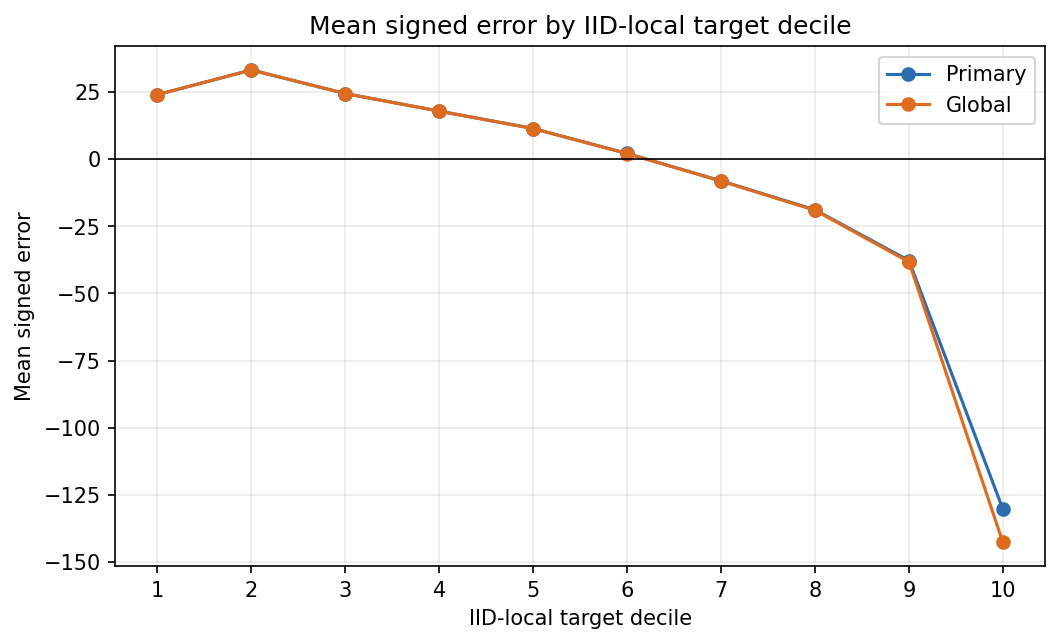

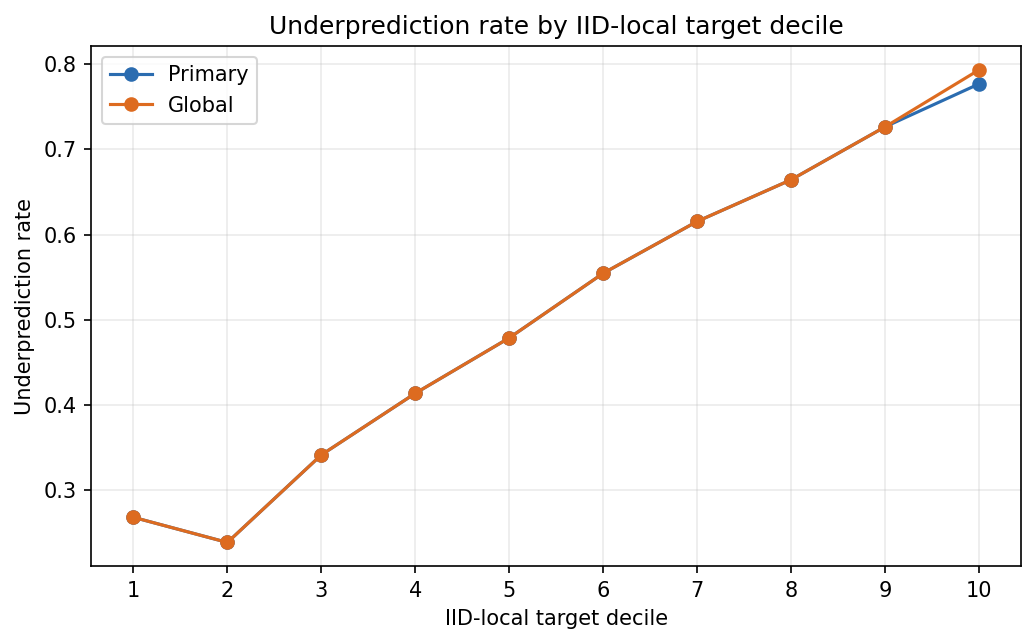

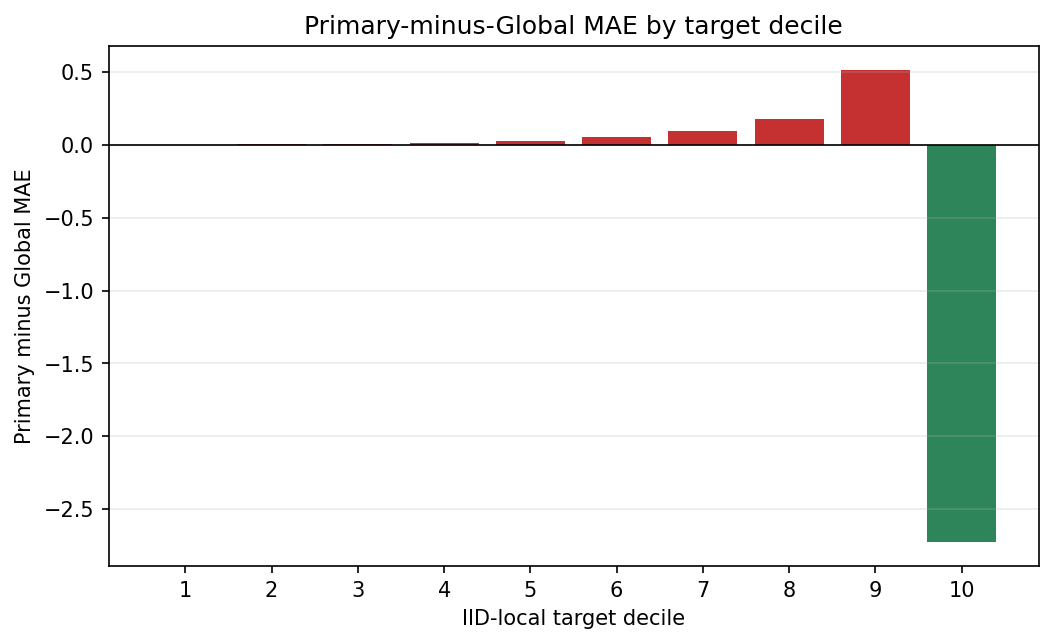

In [4]:
deciles=pd.read_csv(R/'prompt5a_iid_local_decile_metrics.csv')
display(deciles)
for name in ['02_mae_by_decile.png','03_mape_percent_by_decile.png','04_wape_percent_by_decile.png','05_mean_signed_error_by_decile.png','06_underprediction_rate_by_decile.png','07_primary_minus_global_mae_by_decile.png']:
    display(Image(filename=str(F/name)))

## Development-frozen target bands

These absolute bands use the q10-q90 cutpoints frozen before IID.

In [5]:
bands=pd.read_csv(R/'prompt5a_development_frozen_band_metrics.csv')
display(bands)

,model_id,band,band_index,n,target_min,target_max,mean_target,median_target,mean_prediction,median_prediction,mae,mape_percent,mape_invalid_nonpositive_rows,mape_valid_rows,mape_valid_coverage,wape_percent,rmse,mean_signed_error,underprediction_rate
0,final_primary_stage3_500k,B1_le_q10,1,7719,1.0,70.0,36.073714,37.0,60.126968,48.316459,29.278094,104.078923,0,7719,1.0,81.161850,47.905150,24.053254,0.268299
1,final_primary_stage3_500k,B2_q10_q20,2,7366,71.0,110.0,92.147570,93.0,125.401501,116.064479,41.866583,46.359182,0,7366,1.0,45.434278,62.061448,33.253931,0.238800
2,final_primary_stage3_500k,B3_q20_q30,3,7664,111.0,142.0,126.832203,127.0,151.296722,141.386065,38.524686,30.507627,0,7664,1.0,30.374531,59.257046,24.464519,0.341467
3,final_primary_stage3_500k,B4_q30_q40,4,7338,143.0,171.0,156.838921,157.0,174.756952,165.109747,38.653750,24.739948,0,7338,1.0,24.645509,58.183538,17.918031,0.413737
4,final_primary_stage3_500k,B5_q40_q50,5,7495,172.0,202.0,186.958105,187.0,198.401500,188.554098,41.889122,22.375858,0,7495,1.0,22.405620,63.013669,11.443395,0.478719
5,final_primary_stage3_500k,B6_q50_q60,6,7464,203.0,239.0,220.540863,220.0,222.691550,214.538101,44.656468,20.279286,0,7464,1.0,20.248614,63.747374,2.150687,0.554528
6,final_primary_stage3_500k,B7_q60_q70,7,7456,240.0,282.0,260.035274,260.0,251.983493,243.184530,52.311609,20.127824,0,7456,1.0,20.117120,72.853973,-8.051781,0.615343
7,final_primary_stage3_500k,B8_q70_q80,8,7535,283.0,347.0,312.388587,311.0,293.540280,284.543297,62.252486,19.938875,0,7535,1.0,19.927900,85.878580,-18.848306,0.664234
8,final_primary_stage3_500k,B9_q80_q90,9,7482,348.0,438.0,391.989441,393.0,354.240682,341.930425,81.708484,20.817988,0,7482,1.0,20.844562,107.365292,-37.748759,0.726276
9,final_primary_stage3_500k,B10_gt_q90,10,7481,439.0,14400.0,716.854565,592.0,586.515388,499.075858,192.292490,24.281399,0,7481,1.0,26.824477,370.322588,-130.339177,0.776634


## Body, Tail, and error distributions

Signed error is prediction minus truth. Negative values mean underprediction.

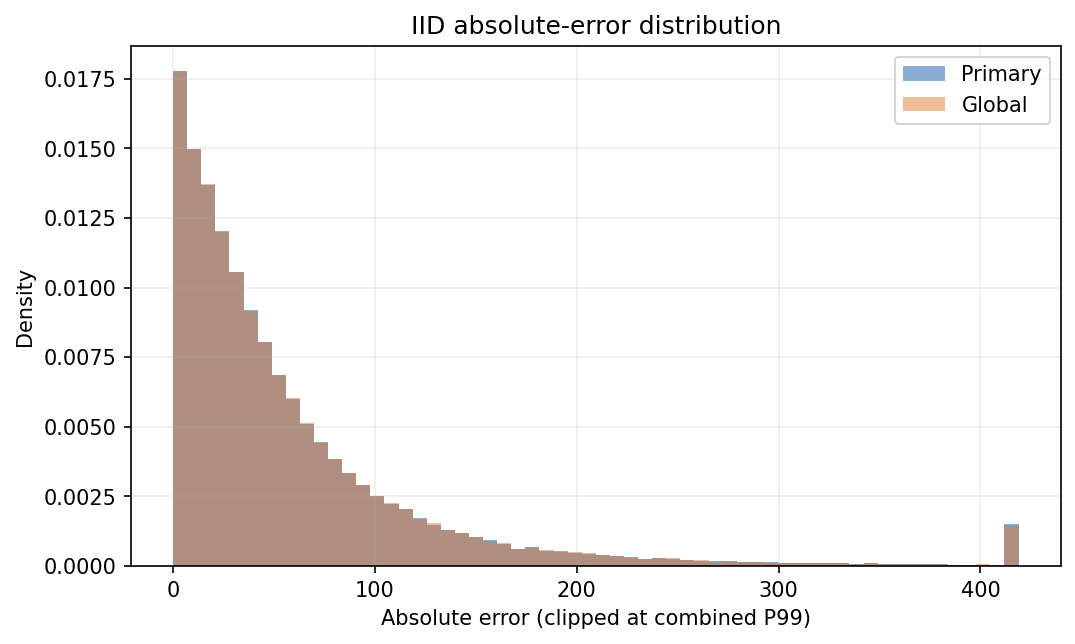

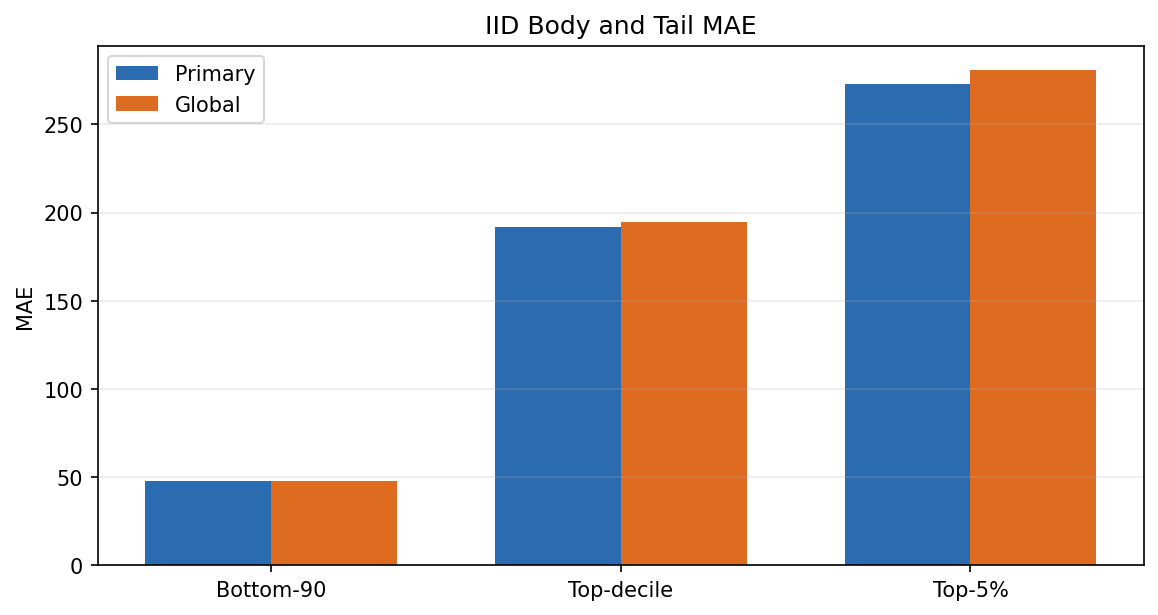

,model_id,scope,n,absolute_error_p50,absolute_error_p75,absolute_error_p90,absolute_error_p95,absolute_error_p99,absolute_error_maximum,signed_error_p01,signed_error_p05,signed_error_p10,signed_error_p50,signed_error_p90,signed_error_p95,signed_error_p99
0,final_primary_stage3_500k,All IID,75000,36.812194,74.745793,133.121315,190.909871,419.663342,13982.451498,-348.818409,-145.337327,-95.682621,-0.745630,80.164926,121.044637,247.261236
1,final_primary_stage3_500k,Bottom-90,67497,33.080924,64.413368,106.927159,140.536826,233.135918,1733.110756,-159.522848,-98.849400,-70.389950,2.181759,79.288294,116.237453,224.118614
2,final_primary_stage3_500k,Top-decile,7503,127.279231,223.963169,383.696105,558.084823,1156.361908,13982.451498,-1148.893211,-504.432179,-348.733015,-100.565526,99.908575,196.069492,488.070956
3,final_primary_stage3_500k,Top-5%,3781,187.563435,323.997410,535.601523,754.709269,1604.627390,13982.451498,-1604.627390,-714.976011,-504.192609,-155.772882,116.707941,218.449975,565.858221
4,final_global_500k,All IID,75000,36.850210,74.833006,133.201254,190.177088,418.150837,13982.451498,-363.027385,-147.582289,-96.753983,-0.930499,79.488520,119.351055,239.461725
5,final_global_500k,Bottom-90,67497,33.080924,64.413368,106.898523,140.365721,232.108302,1538.134891,-159.522848,-98.849400,-70.389950,2.181759,79.276321,116.120557,222.680548
6,final_global_500k,Top-decile,7503,128.370476,224.053072,389.328494,566.172190,1219.026871,13982.451498,-1219.026871,-528.096476,-362.974450,-105.910832,84.368194,167.030778,427.127244
7,final_global_500k,Top-5%,3781,188.549535,330.937915,549.986498,779.576660,1683.899372,13982.451498,-1683.899372,-760.948387,-526.528035,-167.231724,91.444361,177.630591,476.524975


,model_id,scope_type,scope,n,underprediction_rate,mean_underprediction_magnitude,median_underprediction_magnitude,mean_overprediction_magnitude,median_overprediction_magnitude
0,final_primary_stage3_500k,overall,All IID,75000,0.507293,69.357525,38.819119,54.953622,34.797801
1,final_primary_stage3_500k,iid_local_decile,D1,7719,0.268299,9.736972,6.782021,36.443403,23.198539
2,final_primary_stage3_500k,iid_local_decile,D2,7366,0.238800,18.033198,13.990513,49.343473,35.592374
3,final_primary_stage3_500k,iid_local_decile,D3,7664,0.341467,20.587910,16.669808,47.825369,32.887130
4,final_primary_stage3_500k,iid_local_decile,D4,7338,0.413737,25.059076,20.887236,48.247761,33.185201
5,final_primary_stage3_500k,iid_local_decile,D5,7495,0.478719,31.799154,26.721828,51.155262,34.544575
6,final_primary_stage3_500k,iid_local_decile,D6,7464,0.554528,38.326063,32.337647,52.536632,35.186354
7,final_primary_stage3_500k,iid_local_decile,D7,7456,0.615343,49.048543,42.764792,57.531603,38.188109
8,final_primary_stage3_500k,iid_local_decile,D8,7535,0.664234,61.048398,53.794903,64.634485,41.442608
9,final_primary_stage3_500k,iid_local_decile,D9,7482,0.726276,82.239519,73.707509,80.299477,48.562777


In [6]:
display(Image(filename=str(F/'08_absolute_error_distribution.png')))
display(Image(filename=str(F/'09_body_tail_mae.png')))
display(pd.read_csv(R/'prompt5a_error_distribution.csv'))
display(pd.read_csv(R/'prompt5a_underprediction_analysis.csv'))

## Frozen six-condition check

This check describes IID generalization. It cannot change the frozen Primary.

In [7]:
six=json.loads((R/'prompt5a_iid_six_condition_check.json').read_text())
display(pd.DataFrame(six['conditions']))
display(pd.DataFrame([{'status':six['status'],'passed':six['conditions_passed'],'total':six['conditions_total']}]))

,condition,description,metric,operator,threshold,primary_value,global_value,status
0,C1,Primary overall MAE improves over Global,mae,<,62.444349,62.260626,62.444349,PASS
1,C2,Primary Top-decile MAE improves by at least 3%,top_decile_mae,<=,188.842202,191.966385,194.682683,FAIL
2,C3,Primary Bottom-90 MAE worsens by no more than ...,bottom_90_mae,<=,47.864032,47.842469,47.744671,PASS
3,C4,Primary RMSE worsens by no more than 0.25%,rmse,<=,137.740685,134.920181,137.397192,PASS
4,C5,Primary Top-decile signed error is closer to zero,top_decile_signed_error,abs(primary) < abs(global),142.355856,-129.973885,-142.355856,PASS
5,C6,Primary Top-decile underprediction rate decreases,top_decile_underprediction_rate,<,0.792350,0.775956,0.792350,PASS


,status,passed,total
0,PARTIAL,5,6


## Paired IID bootstrap uncertainty

The same resampled rows were used for both models in all 500 resamples with seed 42.

,metric,observed_difference_primary_minus_global,bootstrap_mean,bootstrap_median,percentile_2_5,percentile_97_5,fraction_primary_lower,n_resamples,seed
0,MAE,-0.183723,-0.183492,-0.184574,-0.262989,-0.104811,1.0,500,42
1,RMSE,-2.477011,-2.454021,-2.432419,-3.514729,-1.542489,1.0,500,42
2,MAPE,0.030244,0.030365,0.030260,0.022524,0.038501,0.0,500,42
3,WAPE,-0.073623,-0.073511,-0.073983,-0.104840,-0.041947,1.0,500,42
4,Bottom-90 MAE,0.097799,0.098034,0.097687,0.081441,0.114905,0.0,500,42
5,Top-decile MAE,-2.716298,-2.715244,-2.720549,-3.472434,-1.939967,1.0,500,42
6,Top-5% MAE,-7.548490,-7.550688,-7.566098,-9.028809,-6.139156,1.0,500,42


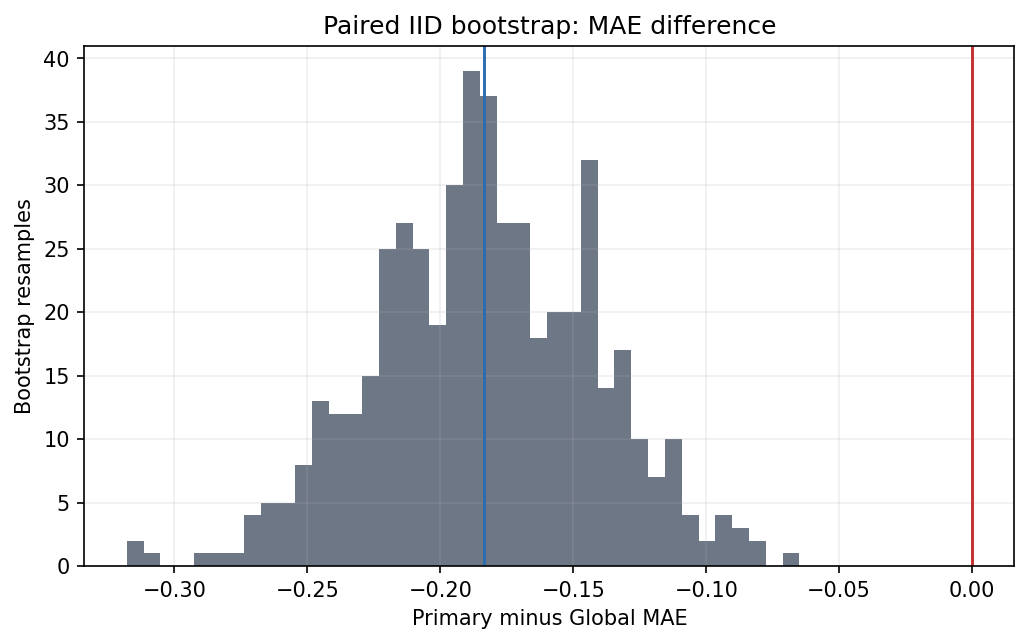

In [8]:
display(pd.read_csv(R/'prompt5a_iid_bootstrap.csv'))
display(Image(filename=str(F/'10_bootstrap_mae_difference.png')))

## Row-level win/loss and large-error concentration

Only aggregate results are displayed here. The sealed evaluation frame stores the row-level analysis data.

In [9]:
display(pd.read_csv(R/'prompt5a_primary_vs_global_rowwise.csv'))
display(pd.read_csv(R/'prompt5a_large_error_analysis.csv'))

,scope,n,fraction_primary_better,fraction_global_better,exact_ties,tie_fraction,mean_primary_improvement_on_primary_win_rows,median_primary_improvement_on_primary_win_rows,mean_primary_damage_on_global_win_rows,median_primary_damage_on_global_win_rows
0,All IID,75000,0.025853,0.021920,71417,0.952227,29.628779,16.765748,26.563841,14.905968
1,D1,7719,0.000000,0.000000,7719,1.000000,NaN,NaN,NaN,NaN
2,D2,7366,0.000000,0.000407,7363,0.999593,NaN,NaN,9.851146,13.683238
3,D3,7664,0.000000,0.000261,7662,0.999739,NaN,NaN,11.291675,11.291675
4,D4,7338,0.000000,0.000954,7331,0.999046,NaN,NaN,15.090337,11.457402
5,D5,7495,0.000000,0.001334,7485,0.998666,NaN,NaN,20.864604,13.580347
6,D6,7464,0.000000,0.002947,7442,0.997053,NaN,NaN,17.334151,15.355519
7,D7,7456,0.000000,0.004426,7423,0.995574,NaN,NaN,20.993055,9.868876
8,D8,7535,0.000664,0.009025,7462,0.990312,11.779426,9.747013,20.783163,14.900810
9,D9,7482,0.002807,0.033948,7207,0.963245,6.878156,4.907927,15.714458,8.959085


,subset,threshold,n,mean_target,median_target,mean_primary_prediction,mean_global_prediction,primary_mae,global_mae,primary_mean_signed_error,global_mean_signed_error,primary_underprediction_rate,global_underprediction_rate,fraction_from_iid_d10,fraction_from_iid_top_5_percent_target
0,Primary top-5% absolute error,190.909871,3750,709.380800,585.5,587.470760,571.311211,362.634255,364.296451,-121.910040,-138.069589,0.605067,0.605867,0.635467,0.494933
1,Primary top-1% absolute error,419.663342,750,1353.797333,1111.0,926.414362,880.354285,772.320146,782.646220,-427.382971,-473.443048,0.716000,0.717333,0.860000,0.806667


## Frozen Stage 3 routing diagnostics

These values come from the existing deterministic bundle. No threshold was changed.

,scope,n,routed_rows,routed_fraction,mean_applied_correction,median_applied_correction,correction_abs_p50,correction_abs_p90,correction_abs_p95,correction_abs_p99,primary_mae_routed,global_mae_routed,primary_advantage_routed,primary_damage_on_routed_global_win_rows,primary_mae_non_routed,global_mae_non_routed
0,All IID,75000,3583,0.047773,1.326838,0.000000,0.000000,0.000000,0.000000,39.388432,236.350225,240.195954,3.845729,26.563841,53.526529,53.526529
1,D1,7719,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,D2,7366,3,0.000407,0.004012,0.000000,0.000000,0.000000,0.000000,0.000000,563.602716,553.751571,-9.851146,9.851146,NaN,NaN
3,D3,7664,2,0.000261,0.002947,0.000000,0.000000,0.000000,0.000000,0.000000,636.586137,625.294462,-11.291675,11.291675,NaN,NaN
4,D4,7338,7,0.000954,0.014395,0.000000,0.000000,0.000000,0.000000,0.000000,464.584157,449.493820,-15.090337,15.090337,NaN,NaN
5,D5,7495,10,0.001334,0.027838,0.000000,0.000000,0.000000,0.000000,0.000000,548.373157,527.508554,-20.864604,20.864604,NaN,NaN
6,D6,7464,22,0.002947,0.051092,0.000000,0.000000,0.000000,0.000000,0.000000,423.638360,406.304210,-17.334151,17.334151,NaN,NaN
7,D7,7456,33,0.004426,0.092915,0.000000,0.000000,0.000000,0.000000,0.000000,429.150393,408.157339,-20.993055,20.993055,NaN,NaN
8,D8,7535,73,0.009688,0.179742,0.000000,0.000000,0.000000,0.000000,0.000000,368.701542,350.148694,-18.552848,20.783163,NaN,NaN
9,D9,7482,275,0.036755,0.515483,0.000000,0.000000,0.000000,0.000000,18.574790,250.004918,236.015713,-13.989204,15.714458,NaN,NaN


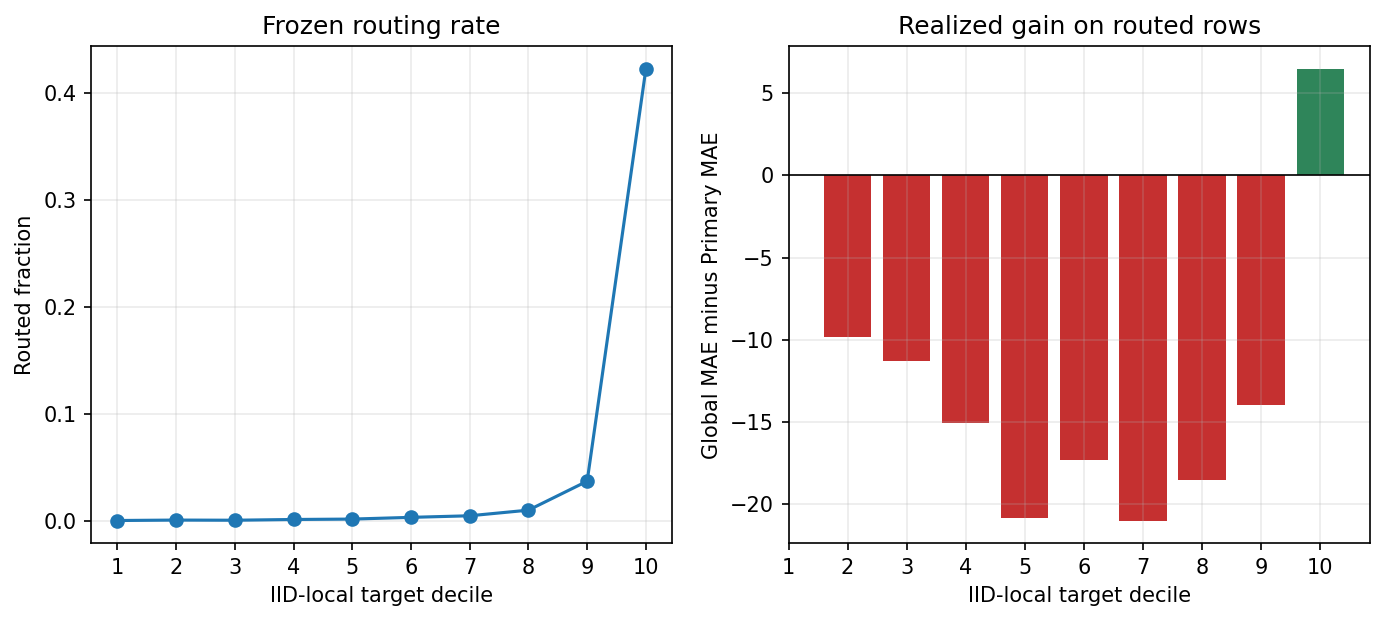

In [10]:
display(pd.read_csv(R/'prompt5a_routing_diagnostics.csv'))
display(Image(filename=str(F/'11_routing_fraction_and_gain.png')))

## Development-to-IID transport

Development was adaptive. IID is the final untouched holdout, so the differences are descriptive.

In [11]:
display(pd.read_csv(R/'prompt5a_development_iid_transport.csv'))

,model_id,development_evidence_label,iid_evidence_label,development_mae,iid_mae,mae_absolute_change_iid_minus_development,mae_relative_change_percent,development_mape_percent,iid_mape_percent,development_wape_percent,iid_wape_percent,development_bottom_90_mae,iid_bottom_90_mae,development_top_decile_mae,iid_top_decile_mae,development_top_decile_underprediction_rate,iid_top_decile_underprediction_rate,interpretation_rule
0,final_primary_stage3_500k,adaptive Development Validation,final untouched IID holdout,62.196656,62.260626,0.063970,0.102851,34.338458,33.560168,24.995015,24.949717,47.669010,47.842469,192.756864,191.966385,0.777290,0.775956,descriptive comparison only; Development was a...
1,final_global_500k,adaptive Development Validation,final untouched IID holdout,62.356316,62.444349,0.088034,0.141179,34.305027,33.529924,25.059178,25.023341,47.576966,47.744671,195.178575,194.682683,0.793968,0.792350,descriptive comparison only; Development was a...


## Closure and later-stage boundary

The final model was not changed after IID. The original IID files are closed after this one-time evaluation. Parts 2 and 3 must use the immutable post-IID snapshots and saved Prompt 5A evidence only.

In [12]:
manifest=json.loads((R/'prompt5a_post_iid_snapshot_manifest.json').read_text())
display(pd.DataFrame([{'artifact':k,**{'rows':v['rows'],'sha256':v['sha256']}} for k,v in manifest['artifacts'].items()]))

,artifact,rows,sha256
0,iid_model_features_snapshot,75000,bded42a0d76bf44fe2f2da93da28459b4bf976d53e1b41...
1,iid_fairness_audit_snapshot,75000,d781d94255d58df3604f9d98ecb4d98b009f91ad92e33c...
2,iid_target_snapshot,75000,f25d1da0a2d076f29bcf07e281fde0df98f9ef38400ba8...
3,iid_evaluation_frame,75000,023964b1e8c9f035d75191ebf7174f70c73c2657db97d8...
4,primary_prediction,75000,c6bd8b0ac2a677bb823cb7f7fe08f033cf6093e14af6a6...
5,global_prediction,75000,96cd547adecc07b5314aafbf01e569238a196306427a2c...
